<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/EasyVisa_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Context**

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## **Objective**

* In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

* The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:
    * Facilitate the process of visa approvals.
    * Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

**Data Description**

* The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* **case_id:** ID of each visa application
* **continent:** Information of continent the employee
* **education_of_employee:** Information of education of the employee
* **has_job_experience:** Does the employee has any job experience? Y= Yes; N = No
* **requires_job_training:** Does the employee require any job training? Y = Yes; N = No
* **no_of_employees:** Number of employees in the employer's company
* **yr_of_estab:** Year in which the employer's company was established
* **region_of_employment:** Information of foreign worker's intended region of employment in the US.
* **prevailing_wage:** Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* **unit_of_wage:** Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* **full_time_position:** Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
* **case_status:** Flag indicating if the Visa was certified or denied

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import math

# importing libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# to maintain the number precision
pd.options.display.float_format = '{:.5f}'.format

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# imprting a model for splitting the data into trian & test
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn import metrics
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report
)


# displaying max column
pd.set_option('display.max_columns', None)

In [2]:
# connecting google drive to colab
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [3]:
# Load data
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/EasyVisa.csv')
  print(" 🚀 Data loaded successfuly")
except Exception as a :
  print(a)

 🚀 Data loaded successfuly


In [4]:
# making the copy of original data
df = data.copy()

In [5]:
# checking the table shape

rows, columns = df.shape
print(f"Total Rows : {rows} \nTotal Columns : {columns}")

Total Rows : 25480 
Total Columns : 12


In [6]:
# checking the table info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


* We have total 25480 rows & 12 columns. out of that 3 numerical columns & 9 categorical columns.

In [7]:
# checking the null values
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


* There is no null values are present in table

In [8]:
# checking the duplicate are present or not in table
df.duplicated().sum()

np.int64(0)

* No Duplicate rows are present in table

In [9]:
# checking the table values by head & tail
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20290,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65000,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86000,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03000,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39000,Year,Y,Certified


In [10]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57000,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79000,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85000,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77000,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91000,Year,Y,Certified


In [11]:
# checking the table stats
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.00000,NaN,NaN,NaN,5667.04321,22877.92885,-26.00000,1022.00000,2109.00000,3504.00000,602069.00000
yr_of_estab,25480.00000,NaN,NaN,NaN,1979.40993,42.36693,1800.00000,1976.00000,1997.00000,2005.00000,2016.00000
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.00000,NaN,NaN,NaN,74455.81459,52815.94233,2.13670,34015.48000,70308.21000,107735.51250,319210.27000
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* case_id columns is only for unique identifier for each rows or each entry.
* There are total 6 unique continent, and Asia is on top. like most of the employees from Asia Continent. ( 66% employees from Asia ).
* 40.16% employees are completed there Bachelor's. there are total 4 unique types of Education.
* 58.09% of employees are have there previous work experience.
* All applicants employee going on 5 differnet Region in US. 28% of Employees joining Northeast regions company.
* Some companies are eastablished from a decade & some of these are on ealry established.
* 90% of employees going US for full time postion.

In **no_of_employees** columns, some entries in negative, so here I'm Considering this might be happend at time of data entery. so we are going to convert this Negative number into positive number.

In [12]:
# making negative values to absolute number (positive number)
df['no_of_employees'] = df['no_of_employees'].abs()

In [13]:
# checking the total unique data
cat_column = ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']

for i in cat_column :
  a = df[i].value_counts()
  print(f"{a}\n")
  print("*"* 40)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

****************************************
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

****************************************
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

****************************************
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

****************************************
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64

****************************************
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64

****************************************
full_time_position
Y    22773
N     2707
Name: count, dtype: int64

*

* Here in Table we have **total rows 25480** out of that 17018 cases got **certified for Visa (67%)** & 8462 **cases denied for Visa (33%)**
* it's reasonably balanced (moderately imbalanced, but not severely)

## **EDA**

In [14]:
# Univariate analysis

def histplot_boxplot(df, features:list):

  """
  Plot Histogram and Boxplot for given features.

    Parameters:
    df : pandas.DataFrame
        Input dataset
    features : list
        List of numerical column names

    Returns:
    None
  """

  n_column = 3
  n_rows = math.ceil(len(features)/n_column)
  # Defining the plot size of histogram
  plt.figure(figsize = (18, 3*n_rows))
  # plotting the histplot using features & data
  for j, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, j + 1)
    sns.histplot(data = df, x = feature, kde = True, color = 'skyblue')

    plt.title(f"Histogram of {feature}")
  plt.tight_layout
  plt.show()

    # ploting boxplot using features list & data
  plt.figure(figsize = (18, 3* n_rows))
  for k, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, k + 1)
    sns.boxplot(data = df, x = feature, color = 'lightgreen')

    plt.title(f"Boxplot of {feature}")

  plt.tight_layout
  plt.show()

In [15]:
def count_plot(data, x):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Summary table
    summary = (
        data.groupby(x)
        .size()
        .div(len(data))
        .reset_index(name='Percentage')
    )

    # Figure size based on categories
    n = data[x].nunique()
    plt.figure(figsize=(n * 3, 4))

    # Plot
    plot = sns.countplot(data=data, x=x, palette="viridis")

    # Add labels on bars
    for container in plot.containers:
        plot.bar_label(container)

    plt.title(f"{x} Distribution")
    plt.xlabel(x)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

    return summary

In [16]:
# bi-variate Analysis

def bargraph_plot(data, x, hue):

  summary = data.groupby([x, hue]).size().div(data.shape[0]).reset_index(name = 'Percentage')

  n = data[x].nunique()  # total unique values
  plt.figure(figsize = (n*3.5, 4))   # figure size
  bar_width = min(0.8, max(0.8, 2/n))  # set bar width
  plt.title(f"{x} Vs. {hue}") # title
  plot = sns.countplot(data=data, x = x, hue = hue, palette= "viridis" , width = bar_width)  # plotting graph
  # plt.ylim(0,  data[hue].value_counts().max()) # set bar hight
  for value in plot.containers :   # plotting values on bar
    plot.bar_label(value)
  return summary
  plt.show()

### **Univariate Analysis**

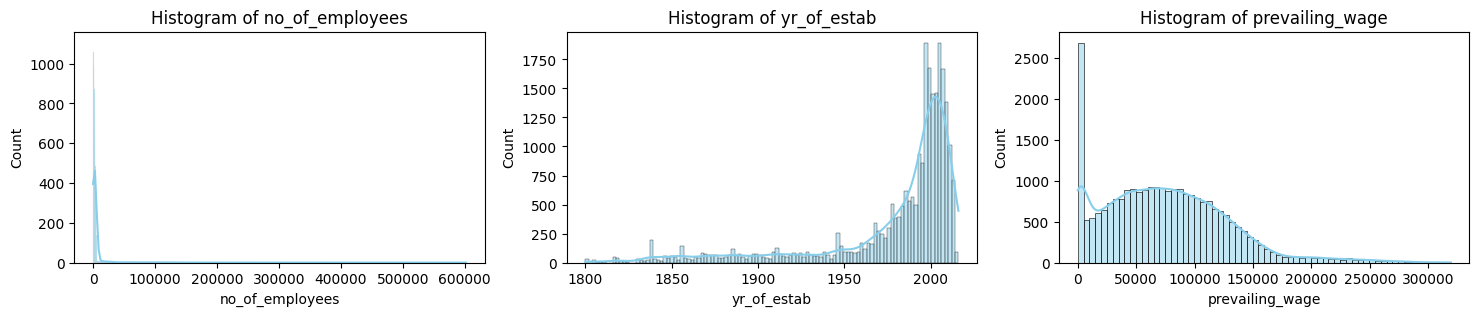

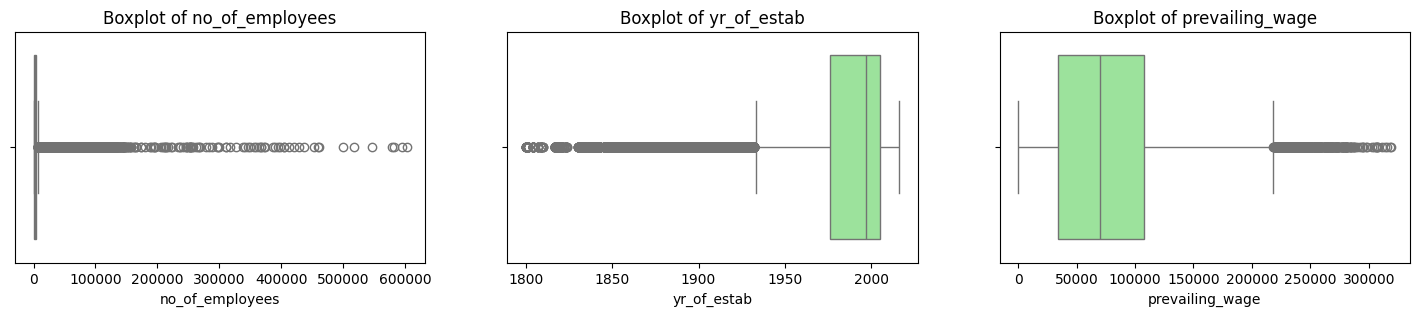

In [17]:
histplot_boxplot(df, ['no_of_employees', 'yr_of_estab', 'prevailing_wage'])

* employee size in companies have hign amount of outliers, not any patterns for employee size in companies.
* Established year of company has highly left side skewed,  some outliers are there in right side.
* 75% of companies has established before around ~2004. year on year more no. of companies establishing.
* 75% of prevailing wages below < 110000. outliers are present.


### **Bivariate Analysis**

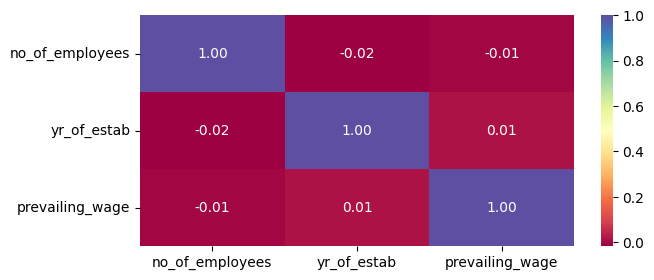

In [18]:
plt.figure(figsize  = (7, 3))
sns.heatmap(data = df.select_dtypes(include = ['number']).corr(), annot = True, cmap= 'Spectral', fmt = '0.2f')
plt.show();

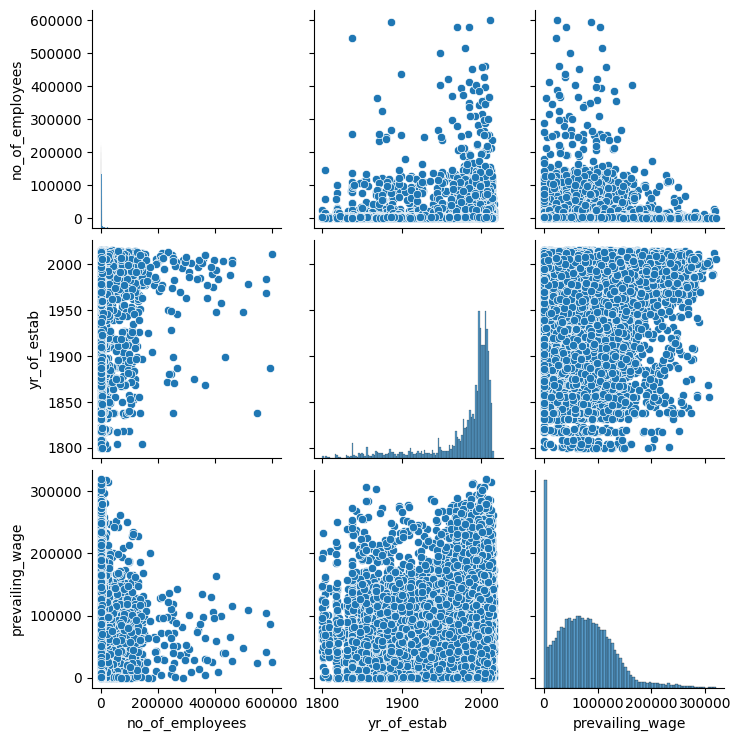

In [19]:
sns.pairplot(df)

* There is no any proper data pattern for employee size & prevailing wage.
* In year of establishment of company & prevailing wage has postive correlartion, after 1900 the more companies establishing & prevailing wages also increases.

,continent,case_status,Percentage
0,Africa,Certified,0.01558
1,Africa,Denied,0.00604
2,Asia,Certified,0.43218
3,Asia,Denied,0.22955
4,Europe,Certified,0.11605
5,Europe,Denied,0.03042
6,North America,Certified,0.07995
7,North America,Denied,0.04925
8,Oceania,Certified,0.00479
9,Oceania,Denied,0.00275


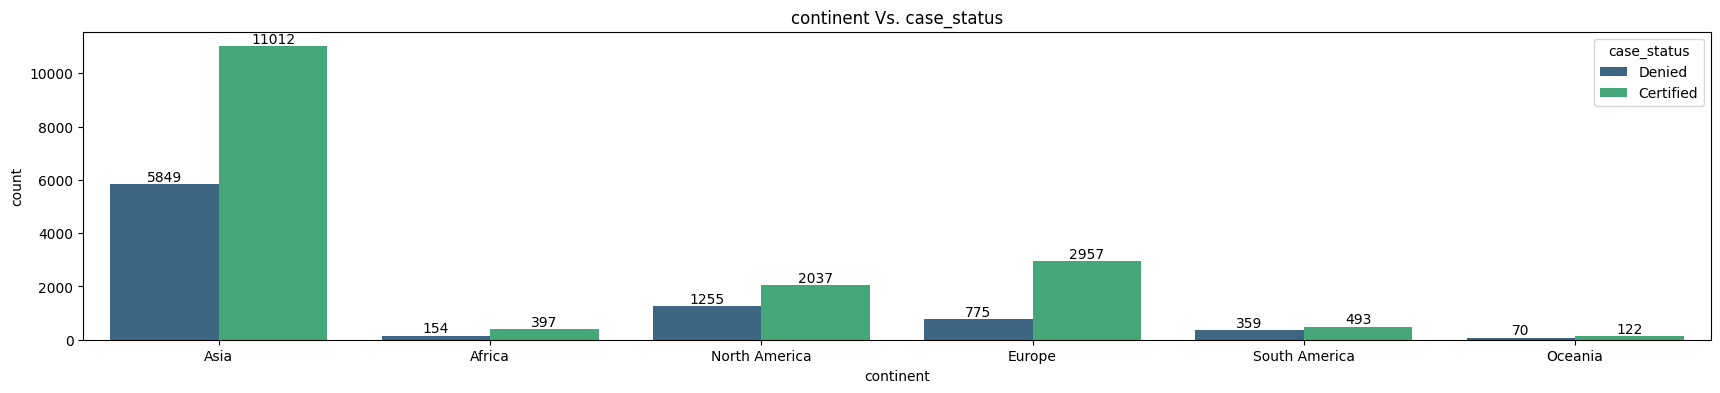

In [20]:
bargraph_plot(df, 'continent', 'case_status')

The Asia region contributes the highest number of US work visa applications, followed by Europe and North America. Among the 16,861 applications filed from Asia, nearly 65% received approval, indicating a comparatively strong approval rate.

,education_of_employee,case_status,Percentage
0,Bachelor's,Certified,0.24988
1,Bachelor's,Denied,0.15177
2,Doctorate,Certified,0.07504
3,Doctorate,Denied,0.01099
4,High School,Certified,0.04568
5,High School,Denied,0.08854
6,Master's,Certified,0.29729
7,Master's,Denied,0.08081


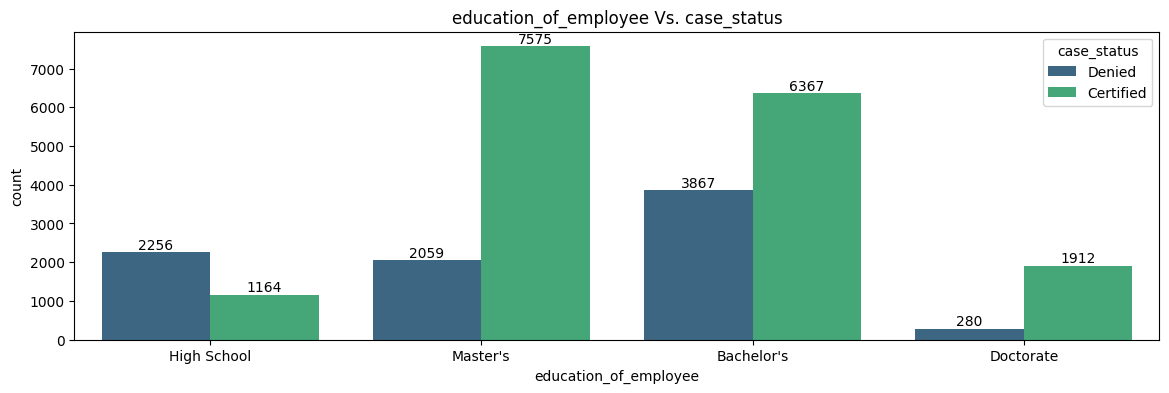

In [21]:
bargraph_plot(df, 'education_of_employee', 'case_status')

Those who are completed there Master's & Bacholer's they got Work visa in US.

,has_job_experience,case_status,Percentage
0,N,Certified,0.23524
1,N,Denied,0.18383
2,Y,Certified,0.43265
3,Y,Denied,0.14827


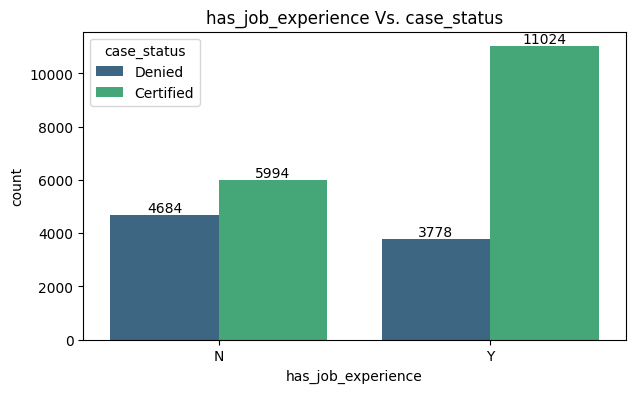

In [22]:
bargraph_plot(df, 'has_job_experience', 'case_status')

Those have ther prior Experience in their filed has more chnace to Application approval for Work in US.

,requires_job_training,case_status,Percentage
0,N,Certified,0.58917
1,N,Denied,0.29486
2,Y,Certified,0.07873
3,Y,Denied,0.03724


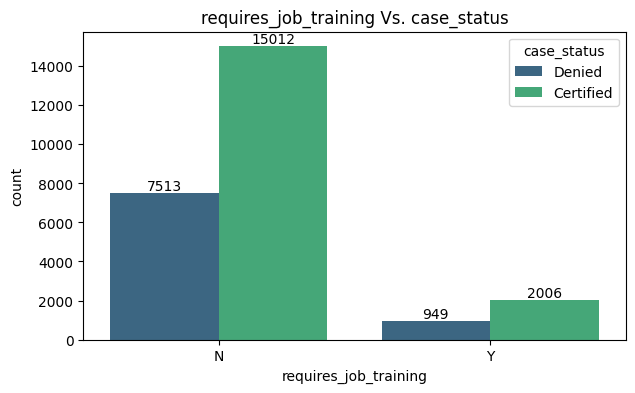

In [23]:
bargraph_plot(df, 'requires_job_training', 'case_status')

Those who not want to training for JOB, they got work Visa application approval/certified.

,region_of_employment,case_status,Percentage
0,Island,Certified,0.00887
1,Island,Denied,0.00585
2,Midwest,Certified,0.12767
3,Midwest,Denied,0.04137
4,Northeast,Certified,0.17763
5,Northeast,Denied,0.10475
6,South,Certified,0.19282
7,South,Denied,0.08257
8,West,Certified,0.16091
9,West,Denied,0.09757


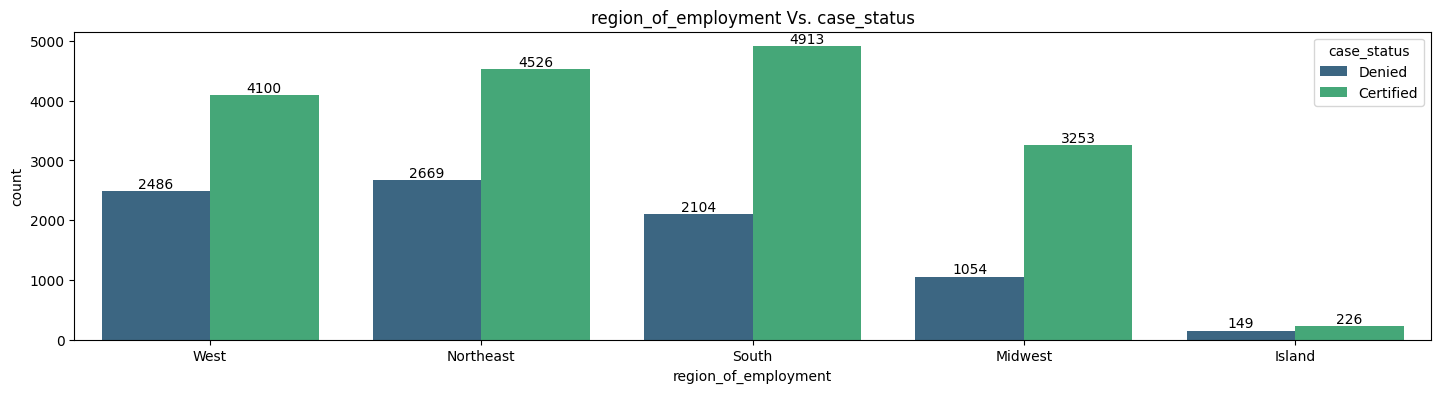

In [24]:
bargraph_plot(df, 'region_of_employment', 'case_status')

Mostly Visa application has raised for work location region, South, Northeast, West, Midwest & last postion on Island.
* For South Region (Comapany Work Location) : total Application has 7017 out of that, 70% of work visa application got certified.
* For Northeast Region : Total 5195 work visa application for this region out of that 87% of application got certified.

,unit_of_wage,case_status,Percentage
0,Hour,Certified,0.02932
1,Hour,Denied,0.05534
2,Month,Certified,0.00216
3,Month,Denied,0.00133
4,Week,Certified,0.00663
5,Week,Denied,0.00404
6,Year,Certified,0.62979
7,Year,Denied,0.27139


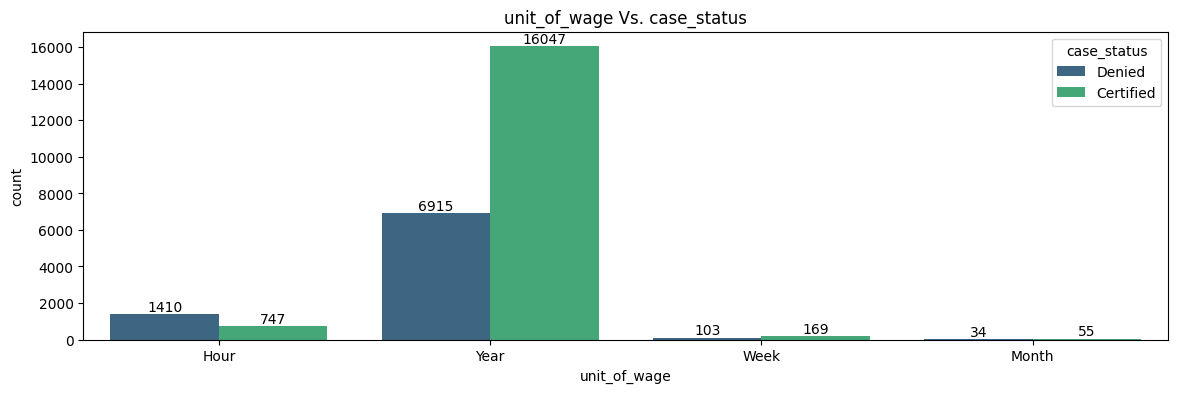

In [25]:
bargraph_plot(df, 'unit_of_wage', 'case_status')

There are 95% of application for work visa raised for Year based wage. from year wage total application git recevied 22962 out of this 70% application got certified.

,full_time_position,case_status,Percentage
0,N,Certified,0.07280
1,N,Denied,0.03344
2,Y,Certified,0.59509
3,Y,Denied,0.29867


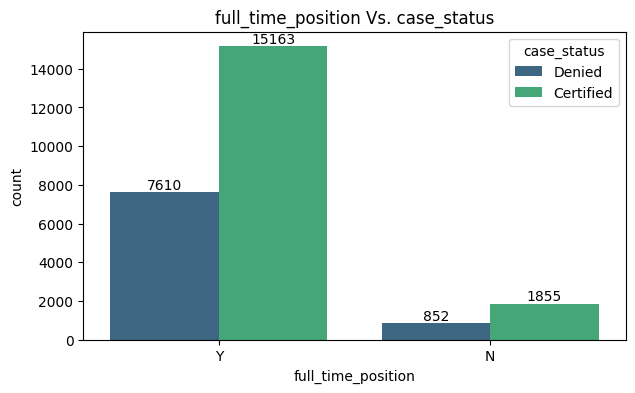

In [26]:
bargraph_plot(df, 'full_time_position', 'case_status')

Mostly Work Visa application recevied for Full time postion. Total no. of Full time position got 22773 out of that 15163 application got Certified for Visa. (~66%).

## **Data Preprocessing**

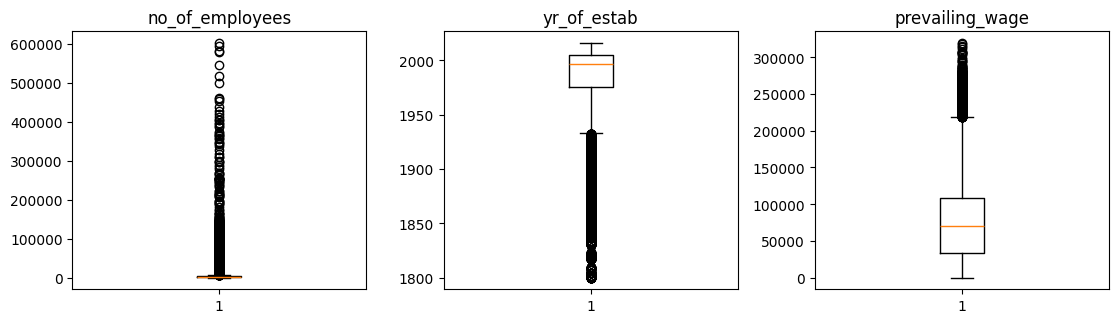

In [27]:
# outlier Detection
numeric_column = df.select_dtypes(include = np.number).columns.tolist()

plt.figure(figsize = (15,12))
for i, variables in enumerate(numeric_column) :
  plt.subplot(4, 4, i+1)
  plt.boxplot(df[variables], whis = 1.5)
  plt.tight_layout()
  plt.title(variables)

plt.show();

* **No of Employees :** Here in Employee size of company is total depend on comapny decision. So some time company want's more workforce to completer project or work in less time or vise versa. so we not going to make changes on this column.

* **Company Establish Yesr :** here also more no. of outliers are present, but this parameters has not conterolled.

* **Prevailing Wage :** Here some time wages are more than gov. rule or any other reason, this parameter is also not controlled by others, this is pure decision on company or farm.


In [28]:
# here we are dropping some unwanted columns for further process.
df.drop(['case_id'], axis = 1, inplace = True)

### **Data Prepration for Model Building**

In [29]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.20290,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.65000,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.86000,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.03000,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.39000,Year,Y,Certified


In [30]:
# splitting the data
X = df.iloc[:, :-1]
y = df['case_status']

In [31]:
# Encoding the categorical variables by get_dummies()
X_dummies = pd.get_dummies(
    X,
    drop_first= True,
    dtype= float
    )

y_dummies = pd.get_dummies(
    y,
    drop_first= True,
    dtype= float
    )

In [32]:
# splitting the data into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X_dummies,
    y_dummies,
    test_size = 0.3,
    random_state = 1,
    stratify=y
)

In [33]:
# checking the shape of train & test data
X_train.shape, X_test.shape

((17836, 21), (7644, 21))

# **Building a Bagging Model's**

### **Define function for Model Evaluation**

In [ ]:
# confusion matrics function

try :
  # ploting a confusion matrics
  def plot_confusion_matrics(model, predictor, target):

    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictor)

    # Compute the confusion matrix compairing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    TN = cm[0,0]
    FP = cm[0,1]
    FN = cm[1,0]
    TP = cm[1,1]

    cm_df = pd.DataFrame({
        "True Negative" : TN,
        "False Positive" : FP,
        "False Negative" : FN,
        "True Positive" : TP
    }, index = [0]).reset_index(drop=True)

    # create a labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format( item / cm.flatten().sum()) for item in cm.flatten()]
        ]
    ).reshape(2, 2)

    plt.figure(figsize = (4,3))

    sns.heatmap(cm, annot = labels, cmap = 'Spectral', fmt = "")

    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")

    return cm_df

  print("Function defined")
except Exception as e :
  print(f"Model Not defined {e}")

In [ ]:
def classification_matrics(model, predicator, target):
  # prediction variable
  pred = model.predict(predicator)

  # confusion matrics
  cm = confusion_matrix(target, pred)
  error_rate = (cm[1,0]+ cm[0,1]) / (cm[0,0] + cm[0,1] + cm[1,0] + cm[1,1])

  # evaluation matrics
  acc = accuracy_score(target, pred)
  prec = precision_score(target, pred)
  recal = recall_score(target, pred)
  f1 = f1_score(target, pred)

  # keeping all matrics in one single df
  evaluation_df = pd.DataFrame({
      "Accuracy" : acc,
      "Precision" : prec,
      "Recall" : recal,
      "F1-Score" : f1,
      "Error Rate" : error_rate
  }, index = [0])

  return evaluation_df

### **Default Decision Tree Classifier**

In [ ]:
# defining the model
simple_dtree = DecisionTreeClassifier(random_state = 1)

In [ ]:
# passing the data into trained model
simple_dtree.fit(X_train, y_train)

In [ ]:
# this is a classification problem so we are going to check Confusino matrics
plot_confusion_matrics(simple_dtree, X_train, y_train)

On train data our model performing well.

In [ ]:
simple_dtree_evaluation_train = classification_matrics(simple_dtree, X_train, y_train)
simple_dtree_evaluation_train

On train data, model giving 100% Accuracy with 100% Rrecall rate. let's check on Test data

In [ ]:
# this is a classification problem so we are going to check Confusino matrics
plot_confusion_matrics(simple_dtree, X_test, y_test)

On unseen data,
* 17.48% of the cases were incorrectly classified as certified by the model, even though the employees were actually not certified for the visa. This represents 1,336 false positive predictions.
* 16.12% of the cases were incorrectly classified as not certified by the model, even though the employee were actually certified for the visa.

In [ ]:
simple_dtree_evaluation_test = classification_matrics(simple_dtree, X_test, y_test)
simple_dtree_evaluation_test

In [ ]:
display("Performance matrics on Train data")
print(f"\n{simple_dtree_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_dtree_evaluation_test}\n")

While the model performed perfectly on the training dataset, the test accuracy decreased sharply to 66%, suggesting that the model is overfitting and struggling to generalize well on unseen data.

### **Default Random Forest Classifier**

In [ ]:
# defining the model
simple_random_forest = RandomForestClassifier(random_state =1)

In [ ]:
# passing the train data into model
simple_random_forest.fit(X_train, y_train)

In [ ]:
# checking the confusion matrics
plot_confusion_matrics(simple_random_forest, X_train, y_train)

In [ ]:
# model performance on train data
simple_randomforest_evaluation_train = classification_matrics(simple_dtree, X_train, y_train)
simple_randomforest_evaluation_train

In [ ]:
# checking the confusion matrics
plot_confusion_matrics(simple_random_forest, X_test, y_test)

In [ ]:
# model performance on test data
simple_randomforest_evaluation_test = classification_matrics(simple_dtree, X_test, y_test)
simple_randomforest_evaluation_test

In [ ]:
display("Performance matrics on Train data")
print(f"\n{simple_randomforest_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_randomforest_evaluation_test}\n")

Model is giving 100% accuracy on train data & 100% recall rate, while on test data accuracy is droped by 34% & recall rate droped by 50% (~49.29)

### **Default Bagging Classifier**

In [ ]:
# defining the model
simple_bagging_classifier = BaggingClassifier(random_state = 1)

In [ ]:
# fitting the data into trained model
simple_bagging_classifier.fit(X_train, y_train)

In [ ]:
# confusin matrics for trained data
plot_confusion_matrics(simple_bagging_classifier, X_train, y_train)

In [ ]:
# checking the model performance on train data
simple_bagging_evaluation_train = classification_matrics(simple_bagging_classifier, X_train, y_train)
simple_bagging_evaluation_train

In [ ]:
# confusin matrics for test data
plot_confusion_matrics(simple_bagging_classifier, X_test, y_test)

In [ ]:
# checking the model performance on test data
simple_bagging_evaluation_test = classification_matrics(simple_bagging_classifier, X_test, y_test)
simple_bagging_evaluation_test

In [ ]:
display("Performance matrics on Train data")
print(f"\n{simple_bagging_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_bagging_evaluation_test}\n")

## **Building Boosting Model's**

### **Default AdaBoost Classifier**

In [ ]:
# defining the model
simple_adaboost_classifier = AdaBoostClassifier(random_state = 1)

In [ ]:
# passing the data into trained model
simple_adaboost_classifier.fit(X_train, y_train)

In [ ]:
# checking the confuison matrics on train data
plot_confusion_matrics(simple_adaboost_classifier, X_train, y_train)

In [ ]:
# checking the model evaluation on train
simple_adaboost_evaluation_train = classification_matrics(simple_adaboost_classifier, X_train, y_train)
simple_adaboost_evaluation_train

In [ ]:
# checking the confuison matrics on test data
plot_confusion_matrics(simple_adaboost_classifier, X_test, y_test)

In [ ]:
# checking the model evaluation on test
simple_adaboost_evaluation_test = classification_matrics(simple_adaboost_classifier, X_test, y_test)
simple_adaboost_evaluation_test

In [ ]:
display("Performance matrics on Train data")
print(f"\n{simple_adaboost_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_adaboost_evaluation_test}\n")

### **Default Gradient Boosting Classifier**

In [ ]:
# Defining the model
simple_gbm_classifier = GradientBoostingClassifier(random_state=1)

In [ ]:
# fitting the data into trained model
simple_gbm_classifier.fit(X_train, y_train)

In [ ]:
# plotting confusion matrics for trian data
plot_confusion_matrics(simple_gbm_classifier, X_train, y_train)

In [ ]:
# checking the evaluation matrics of model on train data
simple_gbm_evaluation_train = classification_matrics(simple_gbm_classifier, X_train, y_train)
simple_gbm_evaluation_train

In [ ]:
# plotting confusion matrics for test data
plot_confusion_matrics(simple_gbm_classifier, X_test, y_test)

In [ ]:
# checking the evaluation matrics of model on train data
simple_gbm_evaluation_test = classification_matrics(simple_gbm_classifier, X_test, y_test)
simple_gbm_evaluation_test

In [ ]:
display("Performance matrics on Train data")
print(f"\n{simple_gbm_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_gbm_evaluation_test}\n")

### **Default XGB Classifier**

In [ ]:
# defining the model
simple_xgb_classifier = XGBClassifier(random_state = 1)

In [ ]:
# fititng the data into model
simple_xgb_classifier.fit(X_train, y_train)

In [ ]:
# checking the confudsion matrics on trian data
plot_confusion_matrics(simple_xgb_classifier, X_train, y_train)

In [ ]:
# checking the model performance on train data
simple_xgbm_evaluation_train = classification_matrics(simple_xgb_classifier, X_train, y_train)
simple_xgbm_evaluation_train

In [ ]:
# checking the confudsion matrics on test data
plot_confusion_matrics(simple_xgb_classifier, X_test, y_test)

In [ ]:
# checking the model performance on train data
simple_xgbm_evaluation_test = classification_matrics(simple_xgb_classifier, X_test, y_test)
simple_xgbm_evaluation_test

In [ ]:
display("Performance matrics on Train data")
print(f"\n{simple_xgbm_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_xgbm_evaluation_test}\n")

# **Models Building on Oversampled Data**

### **Over Sampling Model using SMOTE**

In [78]:
# defining the SMOTE for oversampling
smote = SMOTE(random_state = 1)

# Fitting the X_train, y_train data
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

In [79]:
# checking the balance after overfitting by SMOTE
print("Before SMOTE")
print(y_train.value_counts())
print()

print("After SOMTE")
print(y_train_over.value_counts())

Before SMOTE
Denied 
0.00000    11913
1.00000     5923
Name: count, dtype: int64

After SOMTE
Denied 
0.00000    11913
1.00000    11913
Name: count, dtype: int64


### **Oversampling data Default Decision Tree Classifier**

In [80]:
# Tarining the model on oversampled data
simple_dtree_over_sample = DecisionTreeClassifier(random_state = 1)

In [81]:
# fitting the data into trained model
simple_dtree_over_sample.fit(X_train_over, y_train_over)

DecisionTreeClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,11913,0,0,11913


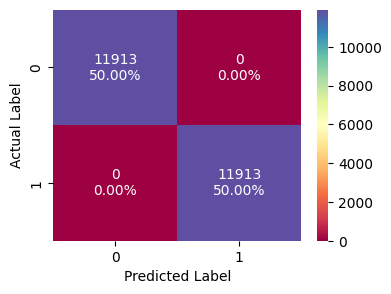

In [82]:
#checking the confusion matrics on trained model
plot_confusion_matrics(simple_dtree_over_sample, X_train_over, y_train_over)

In [83]:
# checking the model evaluation score
simple_dtree_oversample_evaluation_train = classification_matrics(simple_dtree_over_sample, X_train_over, y_train_over)
simple_dtree_oversample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,1.00000,1.00000,1.00000,1.00000,0.00000


,True Negative,False Positive,False Negative,True Positive
0,3802,1303,1285,1254


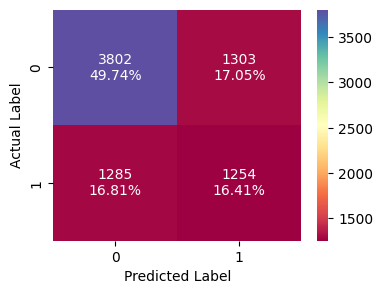

In [84]:
#checking the confusion matrics on trained model
plot_confusion_matrics(simple_dtree_over_sample, X_test, y_test)

In [85]:
# checking the model evaluation score
simple_dtree_oversample_evaluation_test = classification_matrics(simple_dtree_over_sample, X_test, y_test)
simple_dtree_oversample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.66143,0.49042,0.49390,0.49215,0.33857


In [86]:
display("Performance matrics on Train data")
print(f"\n{simple_dtree_oversample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_dtree_oversample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   1.00000    1.00000 1.00000   1.00000     0.00000



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.66143    0.49042 0.49390   0.49215     0.33857



### **Oversampling data Default Random Forest Classifier**

In [87]:
# defining the random forest model for Oversampled data
simple_randomforest_over_sample = RandomForestClassifier(random_state = 1)

In [88]:
# fitting the data into oversampled data Random forest trained model
simple_randomforest_over_sample.fit(X_train_over, y_train_over)

RandomForestClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,11913,0,0,11913


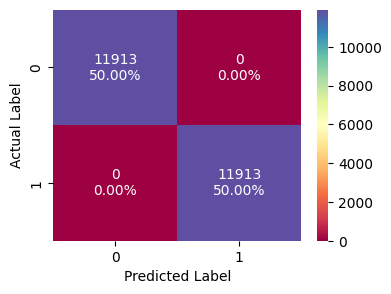

In [89]:
# plotting the confusion matrics
plot_confusion_matrics(simple_randomforest_over_sample, X_train_over, y_train_over)

In [90]:
# checking model evaluation
simple_randomforest_oversample_evaluation_train = classification_matrics(simple_randomforest_over_sample, X_train_over, y_train_over)
simple_randomforest_oversample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,1.00000,1.00000,1.00000,1.00000,0.00000


,True Negative,False Positive,False Negative,True Positive
0,4336,769,1256,1283


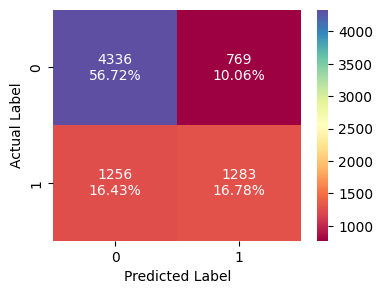

In [91]:
plot_confusion_matrics(simple_randomforest_over_sample, X_test, y_test)

In [92]:
# checking the model performance on test
simple_randomforest_oversample_evaluation_test = classification_matrics(simple_randomforest_over_sample, X_test, y_test)
simple_randomforest_oversample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.73509,0.62524,0.50532,0.55892,0.26491


In [93]:
display("Performance matrics on Train data")
print(f"\n{simple_randomforest_oversample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_randomforest_oversample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   1.00000    1.00000 1.00000   1.00000     0.00000



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.73509    0.62524 0.50532   0.55892     0.26491



### **Oversampling data Default Bagging Classifier**

In [94]:
# defining the baggingclassifier model for Oversampled data
simple_bagging_classifier_over_sample = BaggingClassifier(random_state = 1)

In [95]:
# fitting the data into model
simple_bagging_classifier_over_sample.fit(X_train_over, y_train_over)

BaggingClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,11856,57,334,11579


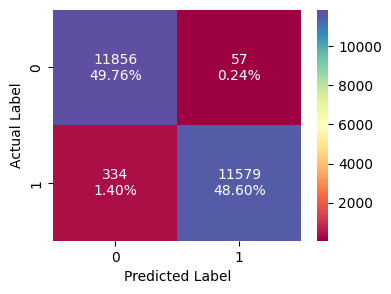

In [96]:
# plotting the confusion matrics
plot_confusion_matrics(simple_bagging_classifier_over_sample, X_train_over, y_train_over)

In [97]:
# checking the model performance on train data
simple_bagging_oversample_evaluation_train = classification_matrics(simple_bagging_classifier_over_sample, X_train_over, y_train_over)
simple_bagging_oversample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.98359,0.99510,0.97196,0.98340,0.01641


,True Negative,False Positive,False Negative,True Positive
0,4325,780,1377,1162


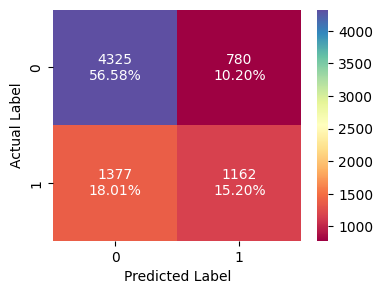

In [98]:
# plotting confusion matrics for test data
plot_confusion_matrics(simple_bagging_classifier_over_sample, X_test, y_test)

In [99]:
# model performance on test data
simple_bagging_oversample_evaluation_test = classification_matrics(simple_bagging_classifier_over_sample, X_test, y_test)
simple_bagging_oversample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.71782,0.59835,0.45766,0.51863,0.28218


In [100]:
display("Performance matrics on Train data")
print(f"\n{simple_bagging_oversample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_bagging_oversample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.98359    0.99510 0.97196   0.98340     0.01641



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.71782    0.59835 0.45766   0.51863     0.28218



### **Oversampled Data Default AdaBoost Classifier**

In [101]:
# defining the Adaboost Classifier model for Oversampled data
simple_adaboost_classifier_over_sample = AdaBoostClassifier(random_state = 1)

In [102]:
# fitting hte data inot trained model
simple_adaboost_classifier_over_sample.fit(X_train_over, y_train_over)

AdaBoostClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,10027,1886,3087,8826


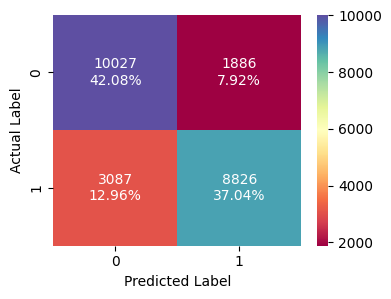

In [103]:
# plotting confusion matrics
plot_confusion_matrics(simple_adaboost_classifier_over_sample, X_train_over, y_train_over)

In [104]:
# checking the model performance
simple_adaboost_oversample_evaluation_train = classification_matrics(simple_adaboost_classifier_over_sample, X_train_over, y_train_over)
simple_adaboost_oversample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.79128,0.82394,0.74087,0.78020,0.20872


,True Negative,False Positive,False Negative,True Positive
0,4300,805,1271,1268


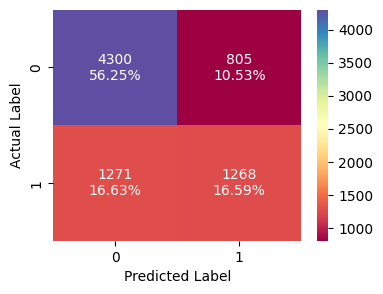

In [105]:
# plotting confusion matrics
plot_confusion_matrics(simple_adaboost_classifier_over_sample, X_test, y_test)

In [106]:
# checking the model performance
simple_adaboost_oversample_evaluation_test = classification_matrics(simple_adaboost_classifier_over_sample, X_test, y_test)
simple_adaboost_oversample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.72841,0.61167,0.49941,0.54987,0.27159


In [107]:
display("Performance matrics on Train data")
print(f"\n{simple_adaboost_oversample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_adaboost_oversample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.79128    0.82394 0.74087   0.78020     0.20872



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.72841    0.61167 0.49941   0.54987     0.27159



### **Oversampled Data Default Gradient Boosting Classifier**

In [108]:
# defining the GBM Classifier model for Oversampled data
simple_GBM_classifier_over_sample = GradientBoostingClassifier(random_state = 1)

In [109]:
# fitting data into trained model
simple_GBM_classifier_over_sample.fit(X_train_over, y_train_over)

GradientBoostingClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,10320,1593,2826,9087


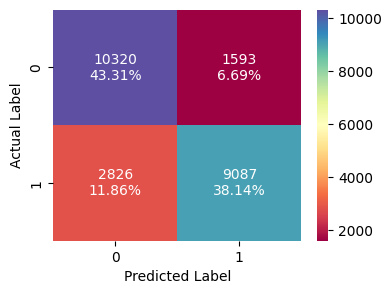

In [110]:
# plotting confusion matrics
plot_confusion_matrics(simple_GBM_classifier_over_sample, X_train_over, y_train_over)

In [111]:
# model performance evaluation
simple_gbm_oversample_evaluation_train = classification_matrics(simple_GBM_classifier_over_sample, X_train_over, y_train_over)
simple_gbm_oversample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.81453,0.85084,0.76278,0.80441,0.18547


,True Negative,False Positive,False Negative,True Positive
0,10320,1593,2826,9087


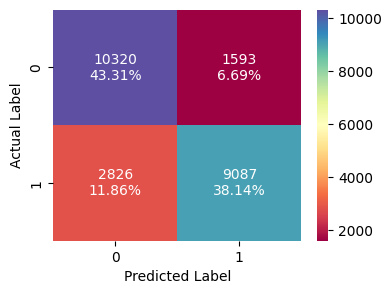

In [112]:
# plotting confusion matrics on test
plot_confusion_matrics(simple_GBM_classifier_over_sample, X_train_over, y_train_over)

In [113]:
# model performance evaluation
simple_gbm_oversample_evaluation_test = classification_matrics(simple_GBM_classifier_over_sample, X_test, y_test)
simple_gbm_oversample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.75170,0.65642,0.52974,0.58631,0.24830


In [114]:
display("Performance matrics on Train data")
print(f"\n{simple_gbm_oversample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_gbm_oversample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.81453    0.85084 0.76278   0.80441     0.18547



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.75170    0.65642 0.52974   0.58631     0.24830



### **Oversampled Data Default XGB Classifier**

In [115]:
# defining the XGBM Classifier model for Oversampled data
simple_XGBM_classifier_over_sample = XGBClassifier(random_state = 1)

In [116]:
# fitting data into model
simple_XGBM_classifier_over_sample.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

,True Negative,False Positive,False Negative,True Positive
0,10989,924,2111,9802


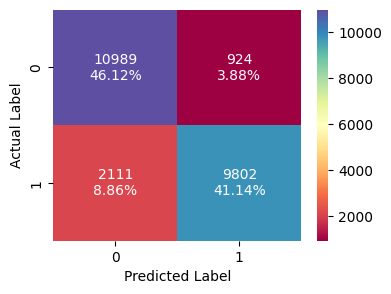

In [117]:
# plotting confusin matrics
plot_confusion_matrics(simple_XGBM_classifier_over_sample, X_train_over, y_train_over)

In [118]:
# checking the model performance
simple_xgbm_oversample_evaluation_train = classification_matrics(simple_XGBM_classifier_over_sample, X_train_over, y_train_over)
simple_xgbm_oversample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.87262,0.91385,0.82280,0.86594,0.12738


,True Negative,False Positive,False Negative,True Positive
0,4354,751,1277,1262


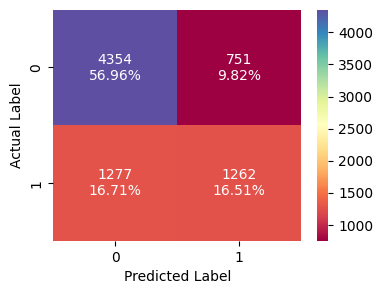

In [119]:
# plotting confusin matrics
plot_confusion_matrics(simple_XGBM_classifier_over_sample, X_test, y_test)

In [120]:
# checking the model performance
simple_xgbm_oversample_evaluation_test = classification_matrics(simple_XGBM_classifier_over_sample, X_test, y_test)
simple_xgbm_oversample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.73469,0.62692,0.49705,0.55448,0.26531


In [121]:
display("Performance matrics on Train data")
print(f"\n{simple_xgbm_oversample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_xgbm_oversample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.87262    0.91385 0.82280   0.86594     0.12738



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.73469    0.62692 0.49705   0.55448     0.26531



# **Models Building on Undersampled Data**

### **Under Sampling Model using Random Undersampler**

In [122]:
# defining undersampling model
rus = RandomUnderSampler(random_state=1)

In [123]:
# splitting the data using undersampling
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

In [124]:
# checking the balance after underampling
print(y_train.value_counts())
print()
print(y_train_under.value_counts())

Denied 
0.00000    11913
1.00000     5923
Name: count, dtype: int64

Denied 
0.00000    5923
1.00000    5923
Name: count, dtype: int64


### **Undersampling data Default Decision Tree Classifier**

In [125]:
# defininig the decisino tree model for under sample
simple_dtree_under_sample = DecisionTreeClassifier(random_state = 1)

In [126]:
# fitting data into trained model
simple_dtree_under_sample.fit(X_train_under, y_train_under)

DecisionTreeClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,5923,0,0,5923


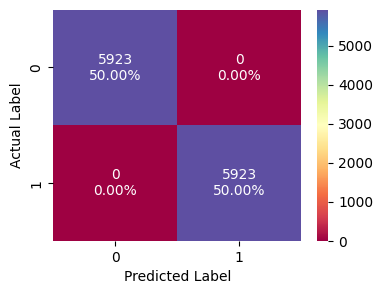

In [127]:
# PLotting confusion matrics
plot_confusion_matrics(simple_dtree_under_sample, X_train_under, y_train_under)

In [128]:
# checking the model performance
simple_dtree_undersample_evaluation_train = classification_matrics(simple_dtree_under_sample, X_train_under, y_train_under)
simple_dtree_undersample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,1.00000,1.00000,1.00000,1.00000,0.00000


,True Negative,False Positive,False Negative,True Positive
0,3215,1890,943,1596


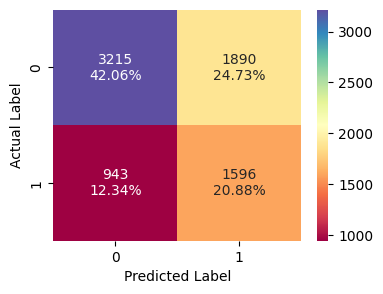

In [129]:
# PLotting confusion matrics
plot_confusion_matrics(simple_dtree_under_sample, X_test, y_test)

In [130]:
# checking the model performance
simple_dtree_undersample_evaluation_test = classification_matrics(simple_dtree_under_sample, X_test, y_test)
simple_dtree_undersample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.62938,0.45783,0.62859,0.52979,0.37062


In [131]:
display("Performance matrics on Train data")
print(f"\n{simple_dtree_undersample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_dtree_undersample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   1.00000    1.00000 1.00000   1.00000     0.00000



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.62938    0.45783 0.62859   0.52979     0.37062



### **Undersampling data Default Random Forest Classifier**

In [132]:
# defininig the Random Forest tree model for under sample
simple_randomForest_under_sample = RandomForestClassifier(random_state = 1)

In [133]:
# fitting data into trained model
simple_randomForest_under_sample.fit(X_train_under, y_train_under)

RandomForestClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,5923,0,0,5923


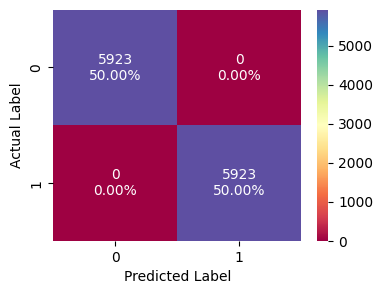

In [134]:
# plotting confusion matrics
plot_confusion_matrics(simple_randomForest_under_sample, X_train_under, y_train_under)

In [135]:
# checking the model performance
simple_randomforest_undersample_evaluation_train = classification_matrics(simple_randomForest_under_sample, X_train_under, y_train_under)
simple_randomforest_undersample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,1.00000,1.00000,1.00000,1.00000,0.00000


,True Negative,False Positive,False Negative,True Positive
0,3575,1530,799,1740


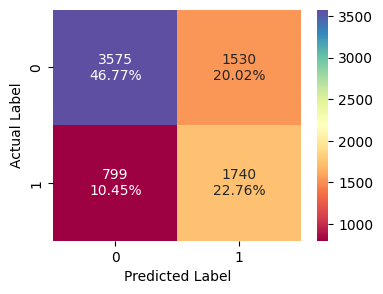

In [136]:
# plotting confusion matrics
plot_confusion_matrics(simple_randomForest_under_sample, X_test, y_test)

In [137]:
# checking the model performance
simple_randomforest_undersample_evaluation_test = classification_matrics(simple_randomForest_under_sample, X_test, y_test)
simple_randomforest_undersample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.69532,0.53211,0.68531,0.59907,0.30468


In [138]:
display("Performance matrics on Train data")
print(f"\n{simple_randomforest_undersample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_randomforest_undersample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   1.00000    1.00000 1.00000   1.00000     0.00000



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.69532    0.53211 0.68531   0.59907     0.30468



### **Undersampling data Default Bagging Classifier**

In [139]:
# defining the baggingclassifier model for Under sampled data
simple_bagging_classifier_under_sample = BaggingClassifier(random_state = 1)

In [140]:
# fitting data into trained model
simple_bagging_classifier_under_sample.fit(X_train_under, y_train_under)

BaggingClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,10129,1784,1151,10762


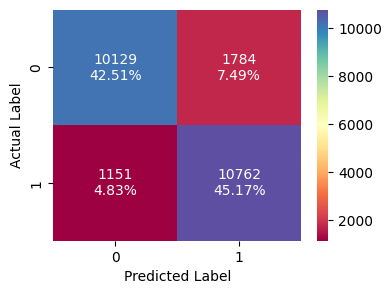

In [141]:
# Plotting confusion matrics
plot_confusion_matrics(simple_bagging_classifier_under_sample, X_train_over, y_train_over)

In [142]:
# checking model performance
simple_bagging_undersample_evaluation_train = classification_matrics(simple_bagging_classifier_under_sample, X_train_over, y_train_over)
simple_bagging_undersample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.87682,0.85780,0.90338,0.88000,0.12318


,True Negative,False Positive,False Negative,True Positive
0,3680,1425,981,1558


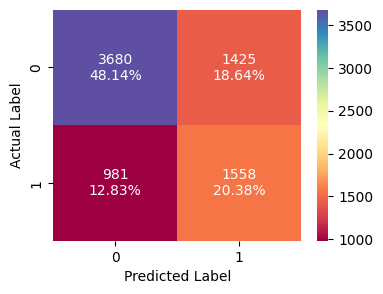

In [143]:
# plotting confusion matrics
plot_confusion_matrics(simple_bagging_classifier_under_sample, X_test, y_test)

In [144]:
# checking the model performance
simple_bagging_undersample_evaluation_test = classification_matrics(simple_bagging_classifier_under_sample, X_test, y_test)
simple_bagging_undersample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.68524,0.52229,0.61363,0.56429,0.31476


In [145]:
display("Performance matrics on Train data")
print(f"\n{simple_bagging_undersample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_bagging_undersample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.87682    0.85780 0.90338   0.88000     0.12318



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.68524    0.52229 0.61363   0.56429     0.31476



### **Undersampled Data Default AdaBoost Classifier**

In [146]:
# defining the Adaboost Classifier model for Undersampled data
simple_adaboost_classifier_under_sample = AdaBoostClassifier(random_state = 1)

In [147]:
# fitting data into model
simple_adaboost_classifier_under_sample.fit(X_train_under, y_train_under)

AdaBoostClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,4270,1653,2006,3917


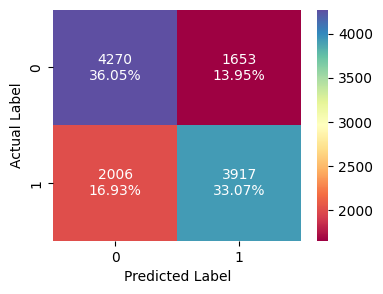

In [148]:
# plotting confusion matrics
plot_confusion_matrics( simple_adaboost_classifier_under_sample, X_train_under, y_train_under)

In [149]:
# checking model performance
simple_adaboost_undersample_evaluation_train = classification_matrics(simple_adaboost_classifier_under_sample, X_train_under, y_train_under)
simple_adaboost_undersample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.69112,0.70323,0.66132,0.68163,0.30888


,True Negative,False Positive,False Negative,True Positive
0,3704,1401,845,1694


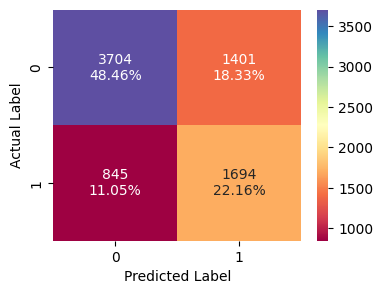

In [150]:
# plotting confusion matrics
plot_confusion_matrics( simple_adaboost_classifier_under_sample, X_test, y_test)

In [151]:
# checking model performance
simple_adaboost_undersample_evaluation_test = classification_matrics(simple_adaboost_classifier_under_sample, X_test, y_test)
simple_adaboost_undersample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.70617,0.54733,0.66719,0.60135,0.29383


In [152]:
display("Performance matrics on Train data")
print(f"\n{simple_adaboost_undersample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_adaboost_undersample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.69112    0.70323 0.66132   0.68163     0.30888



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.70617    0.54733 0.66719   0.60135     0.29383



### **Undersampled Data Default Gradient Boosting Classifier**

In [153]:
# defining the GBM Classifier model for Oversampled data
simple_GBM_classifier_under_sample = GradientBoostingClassifier(random_state = 1)

In [154]:
# fitting data into trained model
simple_GBM_classifier_under_sample.fit(X_train_over, y_train_over)

GradientBoostingClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,5163,760,2779,3144


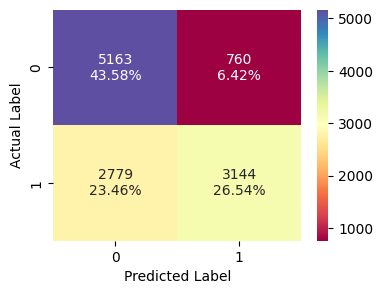

In [155]:
# plotting confusion matrics
plot_confusion_matrics(simple_GBM_classifier_under_sample, X_train_under, y_train_under)

In [156]:
# checking performance matrics
simple_gbm_undersample_evaluation_train = classification_matrics(simple_GBM_classifier_under_sample, X_train_under, y_train_under)
simple_gbm_undersample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.70125,0.80533,0.53081,0.63987,0.29875


,True Negative,False Positive,False Negative,True Positive
0,4401,704,1194,1345


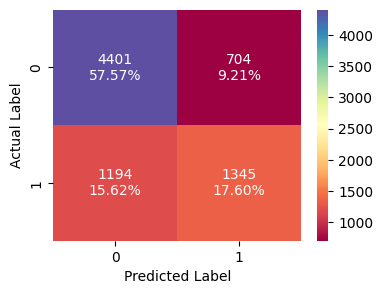

In [157]:
# plotting confusion matrics
plot_confusion_matrics(simple_GBM_classifier_under_sample, X_test, y_test)

In [158]:
# checking performance matrics
simple_gbm_undersample_evaluation_test = classification_matrics(simple_GBM_classifier_under_sample, X_test, y_test)
simple_gbm_undersample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.75170,0.65642,0.52974,0.58631,0.24830


In [159]:
display("Performance matrics on Train data")
print(f"\n{simple_gbm_undersample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_gbm_undersample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.70125    0.80533 0.53081   0.63987     0.29875



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.75170    0.65642 0.52974   0.58631     0.24830



### **Undersampled Data Default XGB Classifier**

In [160]:
# defining the XGBM Classifier model for Undersampled data
simple_XGBM_classifier_under_sample = XGBClassifier(random_state = 1)

In [161]:
# fitting data into trained model
simple_XGBM_classifier_under_sample.fit( X_train_under, y_train_under)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

,True Negative,False Positive,False Negative,True Positive
0,5123,800,903,5020


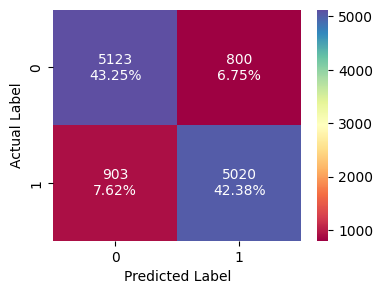

In [162]:
# plot confusion matrics
plot_confusion_matrics(simple_XGBM_classifier_under_sample, X_train_under, y_train_under)

In [163]:
# checking the performance matrics
simple_xgbm_undersample_evaluation_train = classification_matrics(simple_XGBM_classifier_under_sample, X_train_under, y_train_under)
simple_xgbm_undersample_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.85624,0.86254,0.84754,0.85498,0.14376


,True Negative,False Positive,False Negative,True Positive
0,3596,1509,795,1744


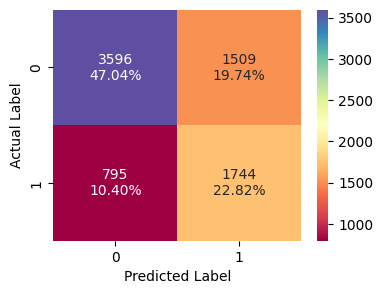

In [164]:
# plot confusion matrics
plot_confusion_matrics(simple_XGBM_classifier_under_sample, X_test, y_test)

In [165]:
# checking the performance matrics
simple_xgbm_undersample_evaluation_test = classification_matrics(simple_XGBM_classifier_under_sample, X_test, y_test)
simple_xgbm_undersample_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.69859,0.53612,0.68688,0.60221,0.30141


In [166]:
display("Performance matrics on Train data")
print(f"\n{simple_xgbm_undersample_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{simple_xgbm_undersample_evaluation_test}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.85624    0.86254 0.84754   0.85498     0.14376



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.69859    0.53612 0.68688   0.60221     0.30141



# **Summary : All Builded Model performances on test data set**

### **Simple Models test Performance**

In [167]:
test_performance_simple_models = pd.concat([
    simple_dtree_evaluation_test.T,
    simple_randomforest_evaluation_test.T,
    simple_bagging_evaluation_test.T,
    simple_adaboost_evaluation_test.T,
    simple_gbm_evaluation_test.T,
    simple_xgbm_evaluation_test.T
], axis = 1)

test_performance_simple_models.columns = [
    "Decision Tree",
    "Random Forest",
    "Bagging Classifier",
    "Adaboost",
    "Gradient Boost",
    "XG Boost"
]

test_performance_simple_models

,Decision Tree,Random Forest,Bagging Classifier,Adaboost,Gradient Boost,XG Boost
Accuracy,0.66313,0.66313,0.71402,0.73744,0.75235,0.73208
Precision,0.49295,0.49295,0.59275,0.65947,0.66753,0.62393
Recall,0.49586,0.49586,0.44427,0.43324,0.50689,0.48681
F1-Score,0.49440,0.49440,0.50788,0.52294,0.57623,0.54690
Error Rate,0.33687,0.33687,0.28598,0.26256,0.24765,0.26792


### **Over Sample data Models test Performance**

In [168]:
test_performance_oversample_models = pd.concat([
    simple_dtree_oversample_evaluation_test.T,
    simple_randomforest_oversample_evaluation_test.T,
    simple_bagging_oversample_evaluation_test.T,
    simple_adaboost_oversample_evaluation_test.T,
    simple_gbm_oversample_evaluation_test.T,
    simple_xgbm_oversample_evaluation_test.T
], axis = 1)

test_performance_oversample_models.columns = [
    "Oversample Decision Tree",
    "Oversample Random Forest",
    "Oversample Bagging Classifier",
    "Oversample Adaboost",
    "Oversample Gradient Boost",
    "Oversample XG Boost"
]

test_performance_oversample_models

,Oversample Decision Tree,Oversample Random Forest,Oversample Bagging Classifier,Oversample Adaboost,Oversample Gradient Boost,Oversample XG Boost
Accuracy,0.66143,0.73509,0.71782,0.72841,0.75170,0.73469
Precision,0.49042,0.62524,0.59835,0.61167,0.65642,0.62692
Recall,0.49390,0.50532,0.45766,0.49941,0.52974,0.49705
F1-Score,0.49215,0.55892,0.51863,0.54987,0.58631,0.55448
Error Rate,0.33857,0.26491,0.28218,0.27159,0.24830,0.26531


### **Under Sample data Models test Performance**

In [169]:
test_performance_undersample_models = pd.concat([
    simple_dtree_undersample_evaluation_test.T,
    simple_randomforest_undersample_evaluation_test.T,
    simple_bagging_undersample_evaluation_test.T,
    simple_adaboost_undersample_evaluation_test.T,
    simple_gbm_undersample_evaluation_test.T,
    simple_xgbm_undersample_evaluation_test.T
], axis = 1)

test_performance_undersample_models.columns = [
    "Undersample Decision Tree",
    "Undersample Random Forest",
    "Undersample Bagging Classifier",
    "Undersample Adaboost",
    "Undersample Gradient Boost",
    "Undersample XG Boost"
]

test_performance_undersample_models

,Undersample Decision Tree,Undersample Random Forest,Undersample Bagging Classifier,Undersample Adaboost,Undersample Gradient Boost,Undersample XG Boost
Accuracy,0.62938,0.69532,0.68524,0.70617,0.75170,0.69859
Precision,0.45783,0.53211,0.52229,0.54733,0.65642,0.53612
Recall,0.62859,0.68531,0.61363,0.66719,0.52974,0.68688
F1-Score,0.52979,0.59907,0.56429,0.60135,0.58631,0.60221
Error Rate,0.37062,0.30468,0.31476,0.29383,0.24830,0.30141


### **Model Selection for Tunning**

### **From Above all models test performances, we are going to choose :-**
* The **Gradient Boosting model** showed superior performance compared to the other baseline models, achieving approximately 75% accuracy on unseen data and a recall score of 0.57, indicating improved capability in identifying positive cases.

* **Oversample Gradient Boost model** from Over sample data models, Among all models trained on the oversampled dataset, the Gradient Boosting model delivered the best overall performance. It achieved nearly 75% accuracy on unseen data with a recall rate of 52%, demonstrating a balanced ability to generalize and identify positive cases effectively.

* The **Undersample XGBoost model** outperformed the other models trained on the undersampled dataset, achieving approximately 69% accuracy and a 68% recall rate on unseen data. This indicates that the model maintains a good balance between overall prediction performance and the ability to correctly identify positive cases.

## **Model Tunning**

### **simple Gradient Boosting Model Tunning**

In [170]:
# using RandomizedSearchCV model we tunning the model
param_grid = {
    'n_estimators': np.arange(50, 500, 50),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

In [171]:
# type of scoring tho used to compare to matrics
score = metrics.make_scorer(metrics.recall_score)

In [172]:
# finding the best estimatores & best parameters
random_search_cv = RandomizedSearchCV(
  estimator = GradientBoostingClassifier(random_state =1),
  param_distributions = param_grid,
  n_iter = 20,
  cv = 5,
  scoring = score,
  verbose= 2,
  random_state = 1,
  n_jobs = -1
)

In [ ]:
# passing the data inot trained model
random_search_cv.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
# finding the best paramenters
best_param = random_search_cv.best_params_
best_param

In [ ]:
# finding the best estimatres
tunned_gbm = random_search_cv.best_estimator_
tunned_gbm

In [ ]:
# checking the confusino matrics on train data
plot_confusion_matrics(tunned_gbm, X_train, y_train)

In [ ]:
# checking the tunned model performance on train data
tunned_gbm_evaluation_train = classification_matrics(tunned_gbm, X_train, y_train)
tunned_gbm_evaluation_train

In [ ]:
# checking the confusino matrics on test data
plot_confusion_matrics(tunned_gbm, X_test, y_test)

In [ ]:
# checking the tunned model performance on train data
tunned_gbm_evaluation_test = classification_matrics(tunned_gbm, X_test, y_test)
tunned_gbm_evaluation_test

In [ ]:
display("Performance matrics on Train data")
print(f"\n{tunned_gbm_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{tunned_gbm_evaluation_test}\n")

* The tuned Gradient Boosting model achieved an accuracy of 75% and a recall score of 57% on the test dataset, whereas the baseline Gradient Boosting model achieved the same accuracy of 75% but a lower recall score of 50%.
* Although hyperparameter tuning did not improve the overall accuracy of the GBM model, it increased the recall score by 7%, indicating better identification of positive cases after tuning.

### **Oversample Gradient Boost Model Tunning**

In [ ]:
# using RandomizedSearchCV model we tunning the model
oversample_param_grid = {
    'n_estimators': np.arange(50, 500, 50),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

In [ ]:
# type of scoring tho used to compare to matrics
oversample_score = metrics.make_scorer(metrics.recall_score)

In [ ]:
# finding the best estimatores & best parameters
oversample_random_search_cv = RandomizedSearchCV(
  estimator = GradientBoostingClassifier(random_state =1),
  param_distributions = oversample_param_grid,
  n_iter = 20,
  cv = 5,
  scoring = score,
  verbose= 2,
  random_state = 1,
  n_jobs = -1
)

In [ ]:
# passing the data inot trained model
oversample_random_search_cv.fit(X_train_over, y_train_over)

In [ ]:
# finding the best paramenters
best_param = oversample_random_search_cv.best_params_
best_param

In [ ]:
# finding the best estimatres
oversample_tunned_gbm = oversample_random_search_cv.best_estimator_
oversample_tunned_gbm

In [ ]:
# checking the confusino matrics on train data
plot_confusion_matrics(oversample_tunned_gbm, X_train_over, y_train_over)

In [ ]:
# checking the tunned model performance on train data
oversample_tunned_gbm_evaluation_train = classification_matrics(oversample_tunned_gbm, X_train_over, y_train_over)
oversample_tunned_gbm_evaluation_train

In [ ]:
# checking the confusino matrics on test data
plot_confusion_matrics(oversample_tunned_gbm, X_test, y_test)

In [ ]:
# checking the tunned model performance on train data
oversample_tunned_gbm_evaluation_test = classification_matrics(oversample_tunned_gbm, X_test, y_test)
oversample_tunned_gbm_evaluation_test

In [ ]:
display("Performance matrics on Train data")
print(f"\n{oversample_tunned_gbm_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{oversample_tunned_gbm_evaluation_test}\n")

* After tuning the Gradient Boosting model on the oversampled dataset, the model achieved an accuracy of 75% and a recall score of 51%, whereas the untuned model achieved the same accuracy of 75% with a slightly higher recall score of 52%.
* Hyperparameter tuning did not lead to any significant improvement in the performance of the Gradient Boosting model on the oversampled dataset, as both accuracy and recall remained nearly unchanged.

### **Undersample XG Boost Model Tunning**

In [ ]:
undersample_param_grid = {
    'n_estimators' : np.arange(100, 600, 50),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

In [ ]:
# type of scoring tho used to compare to matrics
oversample_score = metrics.make_scorer(metrics.recall_score)

In [ ]:
# finding the best estimatores & best parameters
undersample_random_search_cv = RandomizedSearchCV(
  estimator = XGBClassifier(random_state =1),
  param_distributions = undersample_param_grid,
  n_iter = 25,
  cv = 5,
  scoring = score,
  verbose= 2,
  random_state = 1,
  n_jobs = -1
)

In [ ]:
# passing the data inot trained model
undersample_random_search_cv.fit(X_train_under, y_train_under)

In [ ]:
# finding the best paramenters
best_param = undersample_random_search_cv.best_params_
best_param

In [ ]:
# finding the best estimatres
undersample_tunned_Xgbm = undersample_random_search_cv.best_estimator_
undersample_tunned_Xgbm

In [ ]:
# checking the confusion matrics on train data
plot_confusion_matrics(undersample_tunned_Xgbm, X_train_under, y_train_under)

In [ ]:
# checking the tunned model performance on train data
undersample_tunned_Xgbm_evaluation_train = classification_matrics(undersample_tunned_Xgbm,  X_train_under, y_train_under)
undersample_tunned_Xgbm_evaluation_train

In [ ]:
# checking the confusino matrics on test data
plot_confusion_matrics(undersample_tunned_Xgbm, X_test, y_test)

In [ ]:
# checking the tunned model performance on train data
undersample_tunned_Xgbm_evaluation_test = classification_matrics(undersample_tunned_Xgbm, X_test, y_test)
undersample_tunned_Xgbm_evaluation_test

In [ ]:
display("Performance matrics on Train data")
print(f"\n{undersample_tunned_Xgbm_evaluation_train}\n")
display("Performance matrics on Test data")
print(f"\n{undersample_tunned_Xgbm_evaluation_test}\n")

* After tuning the XGBoost model, the accuracy and recall scores on the test dataset were both 69%, whereas before tuning, the model achieved 69% accuracy and 68% recall.
* Hyperparameter tuning did not result in any significant improvement in the overall performance of the XGBoost model, as the evaluation metrics remained almost unchanged before and after tuning.

## **Summary : Tunned Model performance on Test data**

In [ ]:
model_performance_tunned = pd.concat([
    tunned_gbm_evaluation_test.T,
    oversample_tunned_gbm_evaluation_test.T,
    undersample_tunned_Xgbm_evaluation_test.T
], axis = 1)

model_performance_tunned.columns = [
    "Tunned GB Model",
    "Tunned GB Model (Oversample Data)",
    "Tunned XGB Model (Undersample Data)"
]

model_performance_tunned

* Based on the comparative evaluation of all models, the **'Tuned XGBoost model trained on the undersampled dataset' has been selected as the final model**, as it achieved a recall score of 69% along with an F1-score of 60%.
* Although the model’s accuracy is slightly lower compared to other models, the primary business objective is to maximize the identification of certified cases. Therefore, greater importance was given to recall and F1-score rather than overall accuracy.
* The selected model demonstrates a stronger ability to capture positive (certified) cases while maintaining a balanced overall performance, making it more suitable for the business requirement.

## **Feature Importance**

In [ ]:
from xgboost import plot_importance
plt.figure(figsize=(15,10))
plot_importance(undersample_tunned_Xgbm)
plt.show()

##### * **The feature importance analysis indicates that prevailing wage, company size (no_of_employees), and company establishment year (yr_of_estab) are the most influential factors affecting visa certification predictions.**
##### * **Additionally, candidate experience and employment region also contribute to the model’s decision-making process. Features such as wage unit and certain continent categories showed minimal impact on prediction performance.**

# **Final Conclusion & Business Recommendation**

**Final Conclusion :**
* After evaluating multiple classification models, the Tuned XGBoost model trained on the undersampled dataset was selected as the final model based on its balanced performance across key evaluation metrics. Although the model achieved a comparatively lower accuracy of 69%, it delivered the highest recall score of 69% and the best F1-score of 60%, making it more effective in identifying certified cases.

* Since the primary business objective was to maximize the identification of positive (certified) applications, recall and F1-score were prioritized over overall accuracy. The model demonstrated a strong capability to capture a larger proportion of certified cases while maintaining balanced predictive performance.

* Feature importance analysis further revealed that prevailing wage, company size, company establishment year, and candidate work experience were the most influential factors affecting certification predictions.

**Business Recommendation :**
* Based on the model insights, organizations offering competitive wages, having larger workforce sizes, and possessing longer establishment history tend to have higher probabilities of certification approval. Additionally, applicants with prior job experience also show improved certification likelihood.

The business can use this predictive model as a decision-support tool to:

    1) "Identify applications with higher certification probability"
    2) "Prioritize high-potential applications"
    3) "Improve operational efficiency in the visa evaluation process"

* However, since the model still produces some false positive predictions, it should be used as a supporting analytical system rather than a fully automated decision-making solution